The Boolean sensitivity (BS) and the Derrida coefficient (DC) are intimately related. But in my latest plots, this correlation is not clear, so something must be going wrong. In particular, it seemed like the BS and the DC as they are currently calculated are indeed linear, but the correlation constant does not work out to be identical every time. That's a problem.

Here we do the following
- We calculate the correlation constant for various degrees and various resolutions. Hopefully this will give a hint as to where things go wrong
- We calculate the DC directly from the formula of the Derrida plot by taking a Taylor expansion.

In [5]:
# standard preamble for the Notebooks I use

import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.automata import LLNA
from src.simulation import *
from src.analysis import derrida_map_analytical, boolean_sens, get_derrida_arrays, calculate_derrida_coefficient
from src.rules import return_life_like_dict, binary_indices, return_equivalent_rule

from scipy.stats import binom

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
resolution = 3
betas = range(2**resolution)
sigmas = range(2**resolution)
for beta in betas:
    for sigma in sigmas:
        

## For resolution 3

In [10]:
nonequiv_rules = []
equiv_rules = []
resolution = 3
betas = range(2**resolution)
sigmas = range(2**resolution)
for beta in betas:
    born_if = binary_indices(beta)
    for sigma in sigmas:
        survive_if = binary_indices(sigma)
        if (beta, sigma) not in equiv_rules:
            nonequiv_rules.append((beta, sigma))
        beta_equiv, sigma_equiv = return_equivalent_rule(resolution, born_if, survive_if, return_decimals=True)
        equiv_rules.append((beta_equiv, sigma_equiv))
len(nonequiv_rules)

36

In [30]:
degrees = np.arange(1, 9)
delta0_array = np.linspace(0,1,1001)

BS_list_per_degree = []
DC_list_per_degree = []

DC_to_BS_fraction_per_degree = []

for degree in tqdm(degrees, total=len(degrees)):
    BS_list = []
    DC_list = []
    for (beta, sigma) in nonequiv_rules:
        # calculate Boolean sensitivity
        B_set = binary_indices(beta)
        S_set = binary_indices(sigma)
        BS = boolean_sens(resolution, B_set, S_set, degree, norm_degree=False)
        BS_list.append(BS)
        # calculate slope of Derrida plot
        delta1_array = derrida_map_analytical(resolution, B_set, S_set, delta0_array, degree)
        DC = (delta1_array[1] - delta1_array[0]) / (delta0_array[1] - delta0_array[0])
        DC_list.append(DC)
    BS_list_per_degree.append(BS_list)
    DC_list_per_degree.append(DC_list)
    DC_to_BS_fraction = np.max(DC_list) / np.max(BS_list)
    DC_to_BS_fraction_per_degree.append(DC_to_BS_fraction)

BS_array_per_degree = np.array(BS_list_per_degree)
DC_array_per_degree = np.array(DC_list_per_degree)

100%|██████████| 8/8 [00:23<00:00,  2.97s/it]


The ratio between the Boolean sensitivity is a constant within the same degree (I verified this with the code at the bottom of the Notebook), but this constant changes when changing degree. And it does so in a monotonic fashion. Let's plot this relationship.

(0.9, 1.1)

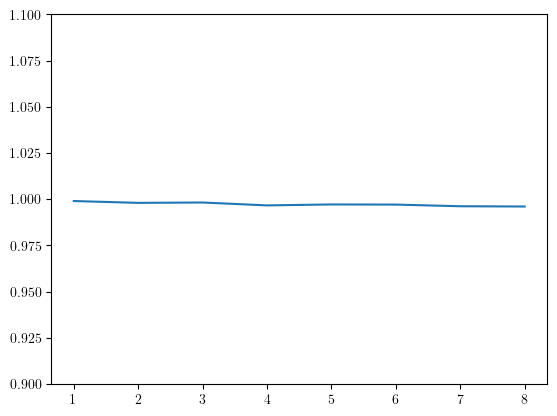

In [31]:
plt.plot(degrees, DC_to_BS_fraction_per_degree)
plt.ylim([0.9,1.1])

So, important conclusion!! The Boolean sensitivity **must not be normalised** to the degree, if we want it to correspond to the Derrida coefficient!

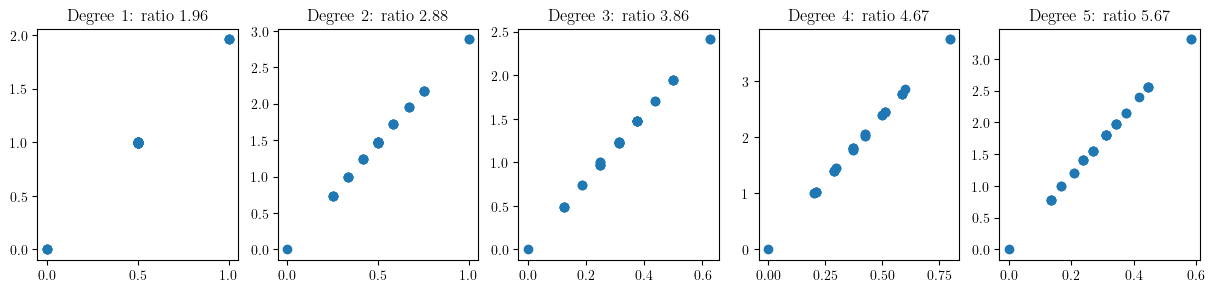

In [23]:
fig, axs = plt.subplots(1,len(degrees), figsize=(15,3))
for i, (ax, degree) in enumerate(zip(axs, degrees)):
    BS_array = BS_array_per_degree[i]
    DC_array = DC_array_per_degree[i]
    ax.scatter(BS_array, DC_array)
    ax.set_title(f"Degree {degree}: ratio {np.round(np.max(DC_array) / np.max(BS_array), 2)}")